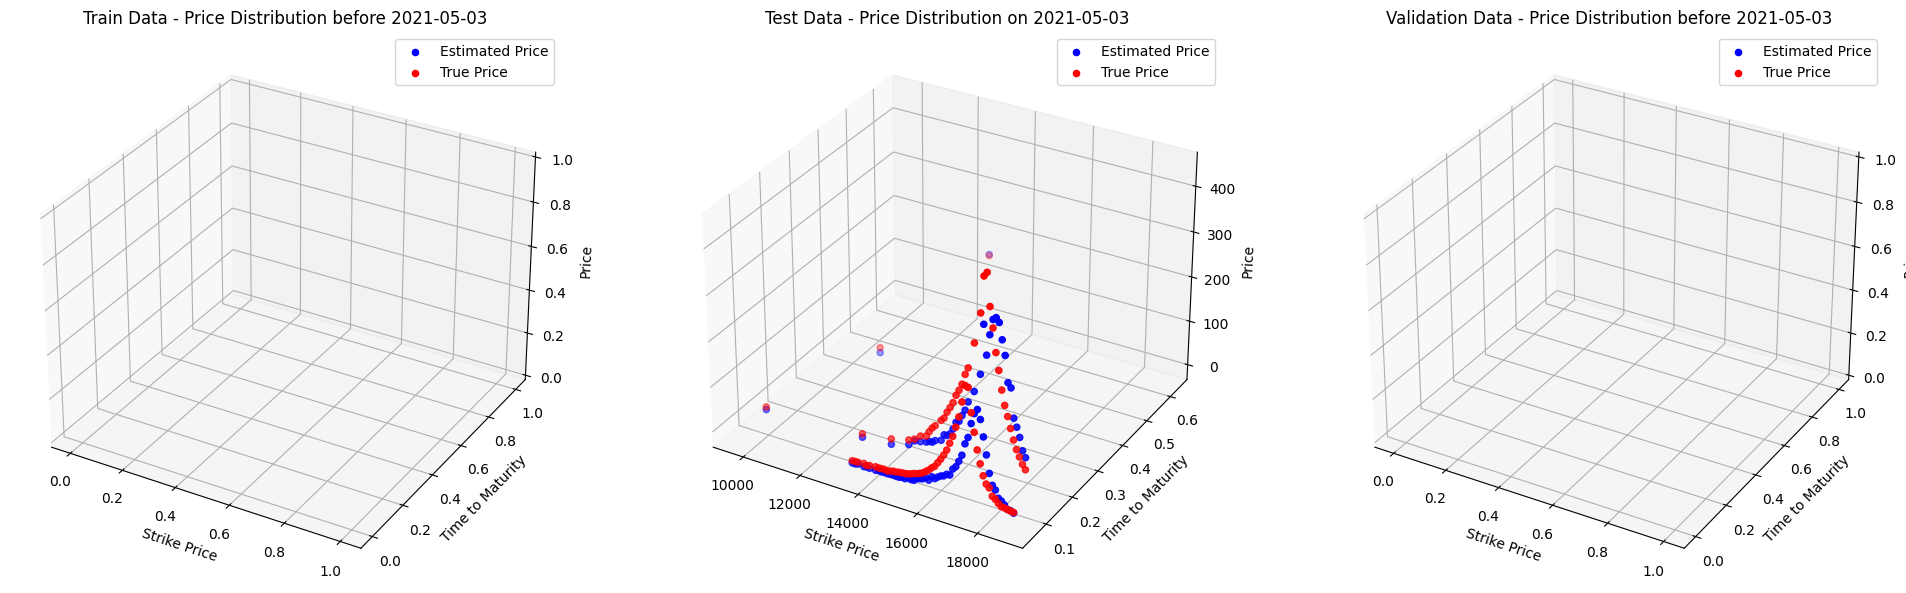

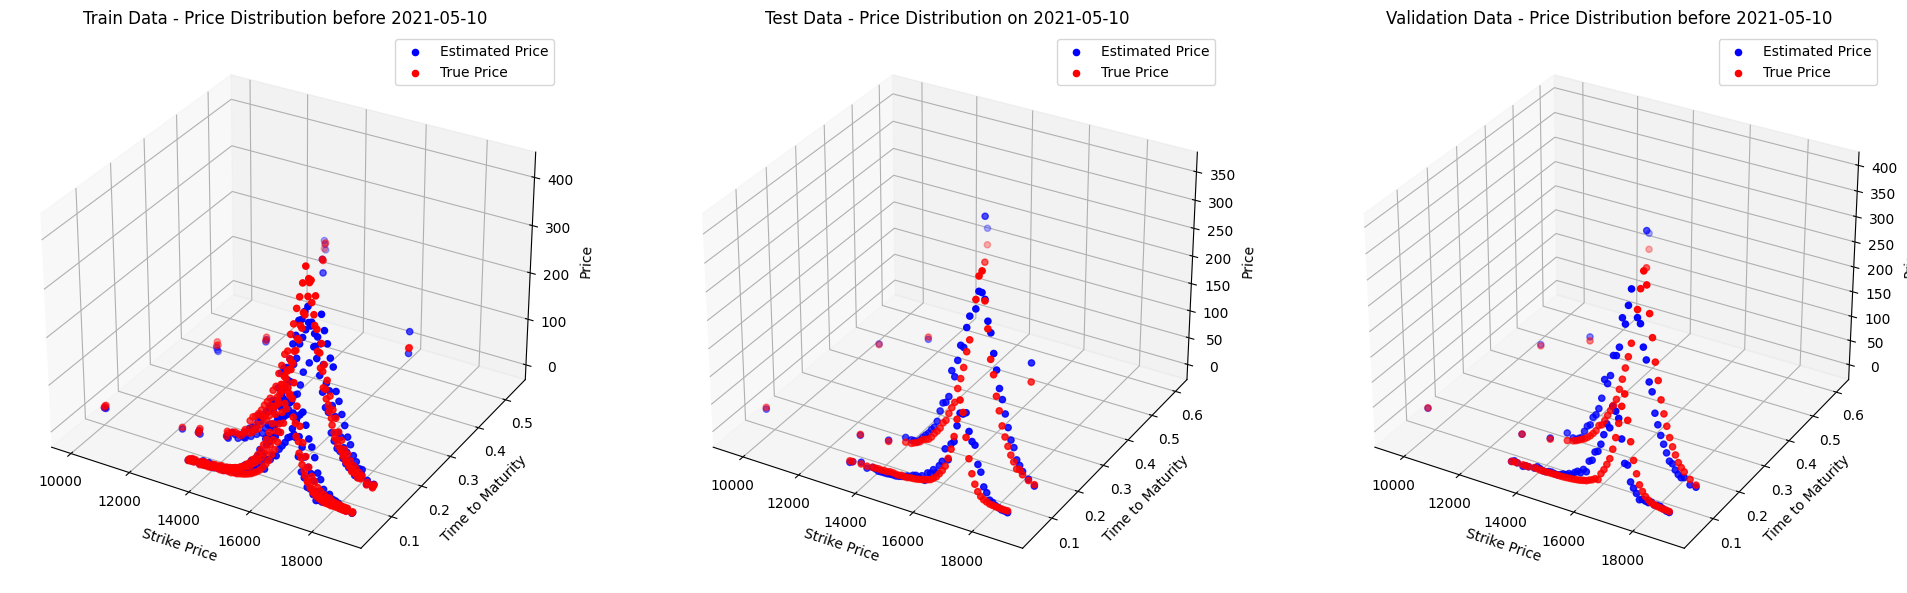

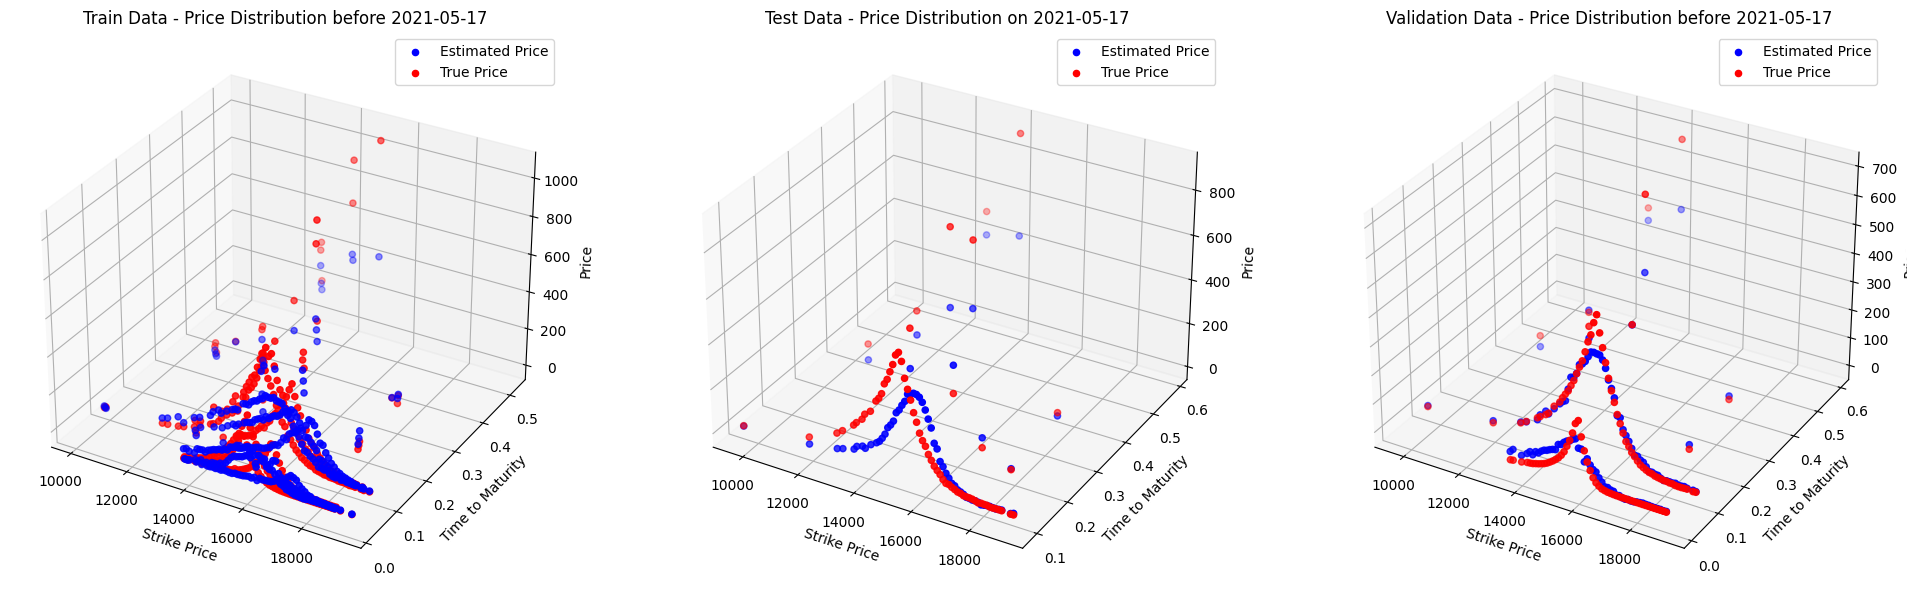

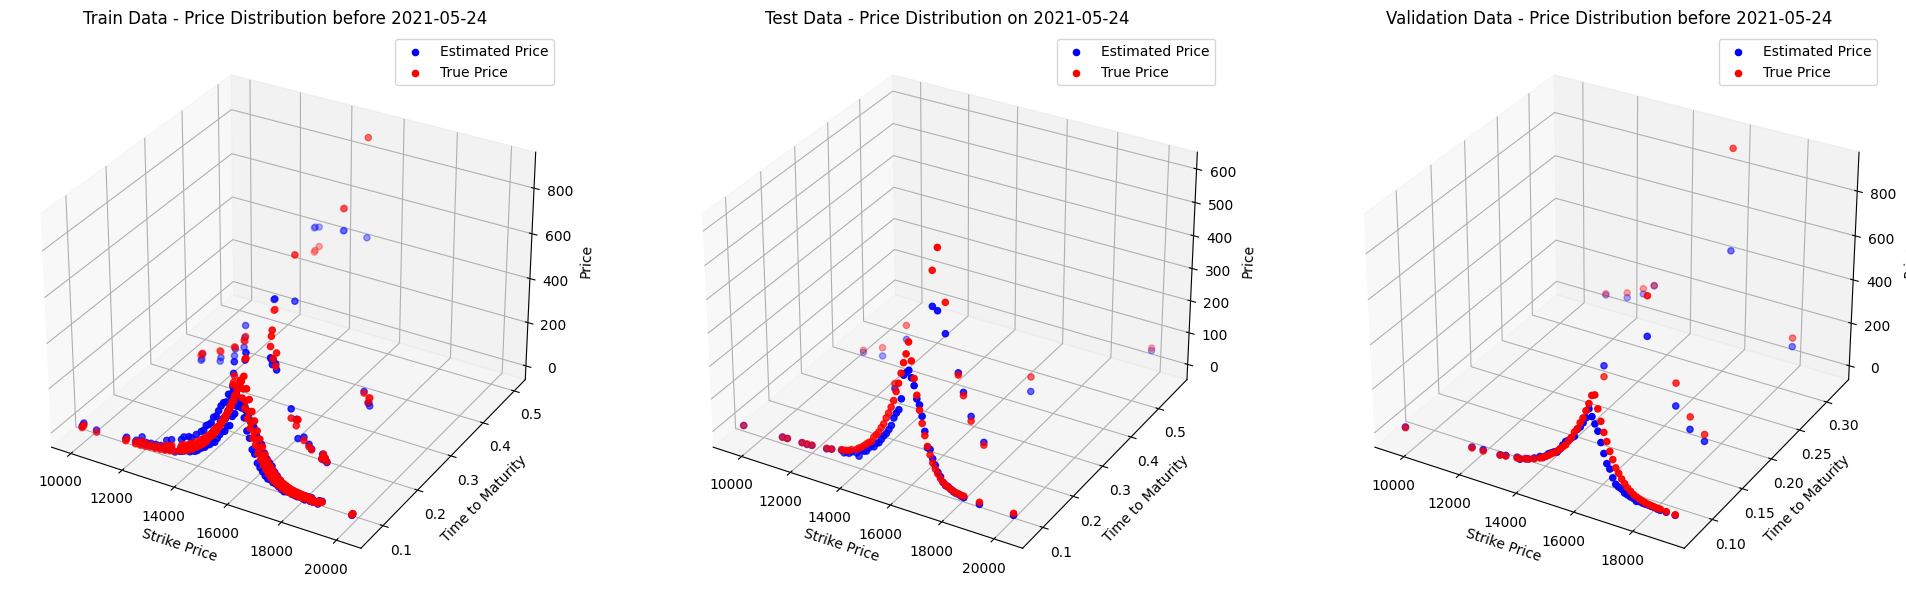

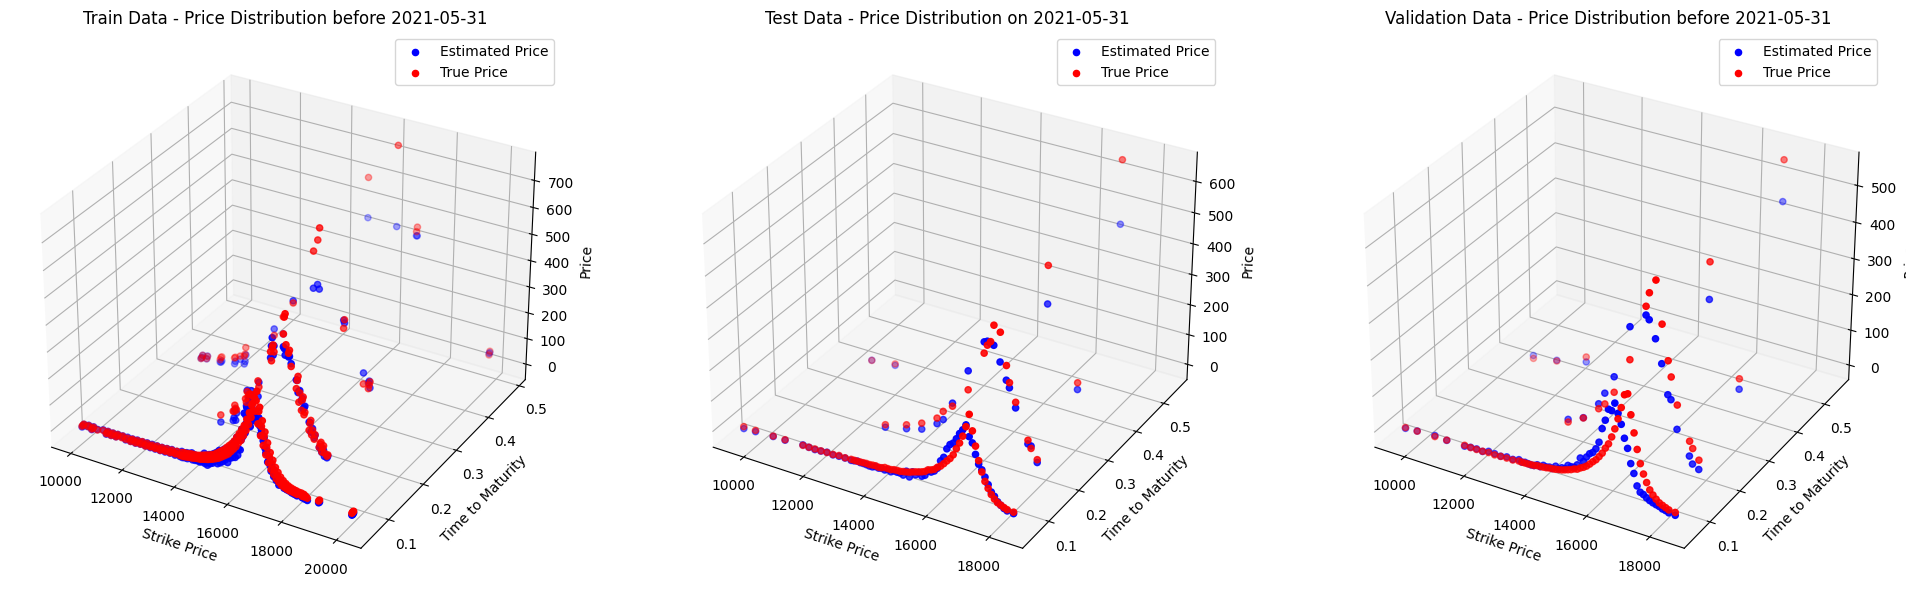

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def parse_date(date_str):
    year, month, day, day_hour = str(date_str).split('.')
    day = str(int(day))
    month = str(int(month))
    return pd.to_datetime(f"{year}-{month}-{day}")

# 讀取訓練、測試和驗證數據
train_df = pd.read_csv('Sep19_195340_convlstm_train_predicted_result.csv')
test_df = pd.read_csv('Sep19_195340_convlstm_test_predicted_result.csv')
valid_df = pd.read_csv('Sep19_195340_convlstm_valid_predicted_result.csv')

# 將 timestamp 轉換為日期時間格式
train_df['date'] = train_df['timestamp'].apply(parse_date)
test_df['date'] = test_df['timestamp'].apply(parse_date)
valid_df['date'] = valid_df['timestamp'].apply(parse_date)

# 篩選5月份的數據
train_df = train_df[train_df['date'].dt.month == 5]
test_df = test_df[test_df['date'].dt.month == 5]
valid_df = valid_df[valid_df['date'].dt.month == 5]


# 提取test_dataset的日期
test_dates = sorted(test_df['date'].dt.date.unique())

# 迭代每個測試日期
for test_date in test_dates:
    # 篩選指定日期的測試數據
    date_test_df = test_df[test_df['date'].dt.date == test_date]
    
    # 獲取對應的驗證日期範圍
    valid_dates = [date for date in sorted(valid_df['date'].dt.date.unique()) if date < test_date][-1:]
    date_valid_df = valid_df[valid_df['date'].dt.date.isin(valid_dates)]
    
    # 獲取對應的訓練日期範圍
    train_dates = [date for date in sorted(train_df['date'].dt.date.unique()) if date < test_date][-3:]
    date_train_df = train_df[train_df['date'].dt.date.isin(train_dates)]
    
    # 創建包含三個子圖的圖形
    fig = plt.figure(figsize=(20, 6))
    
    # 訓練數據子圖
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(date_train_df['strike price'], date_train_df['time to maturity'], date_train_df['estimated price'], c='blue', label='Estimated Price')
    ax1.scatter(date_train_df['strike price'], date_train_df['time to maturity'], date_train_df['true price'], c='red', label='True Price')
    ax1.set_title(f'Train Data - Price Distribution before {test_date}')
    ax1.set_xlabel('Strike Price')
    ax1.set_ylabel('Time to Maturity')
    ax1.set_zlabel('Price')
    ax1.legend()
    
    # 測試數據子圖
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(date_test_df['strike price'], date_test_df['time to maturity'], date_test_df['estimated price'], c='blue', label='Estimated Price')
    ax2.scatter(date_test_df['strike price'], date_test_df['time to maturity'], date_test_df['true price'], c='red', label='True Price')
    ax2.set_title(f'Test Data - Price Distribution on {test_date}')
    ax2.set_xlabel('Strike Price')
    ax2.set_ylabel('Time to Maturity')
    ax2.set_zlabel('Price')
    ax2.legend()
    
    # 驗證數據子圖
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(date_valid_df['strike price'], date_valid_df['time to maturity'], date_valid_df['estimated price'], c='blue', label='Estimated Price')
    ax3.scatter(date_valid_df['strike price'], date_valid_df['time to maturity'], date_valid_df['true price'], c='red', label='True Price')
    ax3.set_title(f'Validation Data - Price Distribution before {test_date}')
    ax3.set_xlabel('Strike Price')
    ax3.set_ylabel('Time to Maturity')
    ax3.set_zlabel('Price')
    ax3.legend()
    
    # 調整子圖間距
    plt.tight_layout()
    
    # 顯示圖表
    plt.show()

2021/5/18 外資大舉回補及融資大減，加上美國疫苗有望來台，激勵台股今天跳空開高，電子、金融、傳產股全面反彈，收16145.98點，勁揚792.09點，超越1989年11月29日上漲590.19點，創史上單日最大漲點。